# Exploratory Data Analysis (EDA)
## Wisconsin Diagnostic Breast Cancer 

_Last Updated: 2026-03-01_

---

# Motivating Problem
_Q: What is the prediction problem you are trying to solve?_

## Approach
_Give an overview of the logic/decision making process of what EDA is relevant to focus on. Make it clear that the EDA is driven by model considerations/assumptions and is targeted (i.e., not simply plotting everything you could think of)_

## Notebook Outline
- [Dataset Overview](#1-dataset-overview)
- [Target Variable Analysis](#2-target-variable-analysis)
- [Univariate Feature Analysis](#3-univaritate-feature-analysis)
    <!-- - [Boxplots & Outlier Detection](#31-boxplots--outlier-detection)
    - [Feature Distribution](#32-feature-distribution) -->
- [Feature Correlation Analysis](#4-feature-correlation-analysis)
- [Preliminary Feature Importance](#5-preliminary-feature-importance)
- [Potential Risks & Unknowns](#6-potential-risks--unknowns)
- [Proposed Modeling Plan](#7-proposed-modeling-plan)

_Note: Jupyter Notebook's within-document hyperlinks do not render on GitHub, but will work if running the .ipynb in an IDE such as VS Code_

# 1. Dataset Overview
<!-- The [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (WDBC) contains 569 samples (instances) of 30 real-valued input features derived from digitized images of fine needle aspirates (FNAs) of breast masses to predict tumor malignancy. Features describe 10 core characteristics of cell nuclei present in the image: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. Each feature is calculated in three ways — mean, standard error, and worst (mean of three largest values). -->
The [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (WDBC) contains 569 samples (instances) of 30 real-valued input features derived from digitized images of fine needle aspirates (FNAs) of breast masses to predict tumor malignancy. Features describe 10 core characteristics of cell nuclei present in the image, and there are three calculations per feature — mean, standard error, and worst (mean of three largest values).

**Target Variable**: 
- **classes**: "Malignant" (0) or "Benign" (1)
- binary classification 

**Core Feature Definitions**:
- **radius**:           mean of distances from the center to points on the perimeter
- **texture**:          standard deviation of gray-scale values
- **perimeter**:        total length of the boundary
- **area**:             surface area of the nucleus
- **smoothness**:       local variation in radius lengths
- **compactness**:      $\mathrm{(perimeter}^2/\mathrm{area)} - 1.0$
- **concavity**:        severity of concave portions of the contour
- **concave points**:   number of concave portions of the contour
- **symmetry**:         surface symmetry
- **fractal dimension**: "coastline approximation" - 1 

**Key Measures**: mean, standard error, worst
<!-- - **mean**: 
- **standard error**: 
- **worst**: -->

<!-- TO DO: Would be better as a formatted table -->

## 1.1 Load and Inspect the Data
Here, we use `sklearn`'s built-in data loader, which mirrors the WDBC dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/) website.

In [98]:
# data manipulation
import pandas as pd
import numpy as np

# dataset
# from ucimlrepo import fetch_ucirepo
from sklearn.datasets import load_breast_cancer

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# processing
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

sns.set_style(style="white")
print("> Loaded required libraries")


> Loaded required libraries


In [99]:
# hard-coded variables or flags go here
cols = {"malignant": "darkblue", "benign": "skyblue"}

In [ ]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names) # add features

# re-map target to categorical: 0=Malignant, 1=Benign
df["diagnosis"] = data.target
df["diagnosis"] = pd.Categorical(
    df["diagnosis"].map({0: "malignant", 1: "benign"}),
    categories = data.target_names
)

# get overview
print(f"Shape of dataset: {df.shape}")
print(f"Target classes ({len(data.target_names)}): {data.target_names}")
print(f"Features ({len(data.feature_names.tolist())}): {data.feature_names.tolist()}\n")

# check that there are 10 features per measurement
measures = ["mean", "error", "worst"]
for i in measures:
    print(f"{len(df.columns[df.columns.str.contains(i)])} {i} features")

df.head() # df snapshot

Shape of dataset: (569, 31)
Target classes (2): ['malignant' 'benign']
Features (30): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

10 mean features
10 error features
10 worst features


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [4]:
# print summary of df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mean radius              569 non-null    float64 
 1   mean texture             569 non-null    float64 
 2   mean perimeter           569 non-null    float64 
 3   mean area                569 non-null    float64 
 4   mean smoothness          569 non-null    float64 
 5   mean compactness         569 non-null    float64 
 6   mean concavity           569 non-null    float64 
 7   mean concave points      569 non-null    float64 
 8   mean symmetry            569 non-null    float64 
 9   mean fractal dimension   569 non-null    float64 
 10  radius error             569 non-null    float64 
 11  texture error            569 non-null    float64 
 12  perimeter error          569 non-null    float64 
 13  area error               569 non-null    float64 
 14  smoothness error     

### Observations:
- df is the correct shape (569, 31), with 30 feature columns consisting of real numbers and 1 target column (`diagnosis`) consisting of 2 categorical variables - malignant and benign 
- there are 10 features per measurement, and feature names are labelled according to whether the measurement represents the `mean`, `error`, or `worst` 
- lack of any missing values reduces preprocessing complexity

## 1.2 Data Cleaning
Before conducting any analyses we need to address data quality issues that could impact model quality and/or stability: missing values, duplicates, and zero-variance features.

In [ ]:
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
zero_var = [col for col in data.feature_names if df[col].nunique() == 1]
print(f"Zero-variance features: {zero_var if zero_var else 'None'}")

Missing values: 0
Duplicate rows: 0
Zero-variance features: None


In [ ]:
# Visualize missing values (if present)
if df.isna().sum().sum() > 0:
    plt.figure(figsize=(10,4))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Missing Value Heatmap")
    plt.show()

In [ ]:
# ensure class label consistency
df["diagnosis"].unique()

['malignant', 'benign']
Categories (2, str): ['malignant', 'benign']

### Observations:
- No missing values reduces preprocessing complexity - no imputation required.
- No exact row duplicates - each observation only contributes once.
- No zero-variance features found - all features have predictive potential.

# 2. Target Variable Analysis
We examine the distribution of the target classes by obtaining class counts and proportions to determine if reporting model accuracy as our primary metric would be misleading due to class imbalance.

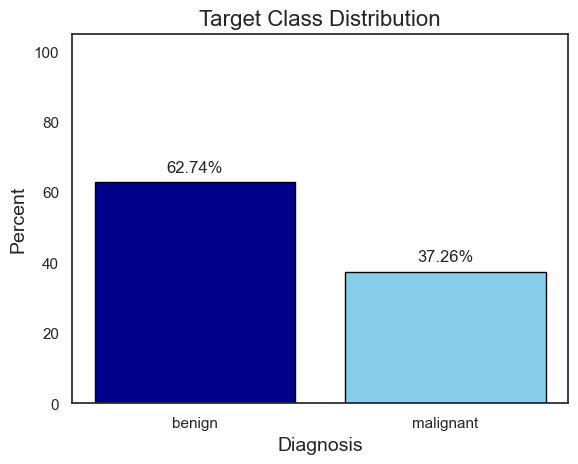

           Count  Percentage (%)
diagnosis                       
benign       357           62.74
malignant    212           37.26


In [ ]:
# calculate diagnosis class counts and percentages
counts = df["diagnosis"].value_counts()
pcts = df["diagnosis"].value_counts(normalize=True) * 100

# create barplot
plt.bar(
    pcts.index,
    pcts.values,
    color = cols.values(),
    edgecolor = "black"
)

# add titles and axes
plt.title("Target Class Distribution", fontsize=16)
plt.xlabel("Diagnosis", fontsize=14)
plt.ylabel("Percent", fontsize=14)
plt.ylim(0, 105)

# add class percentages above bars
for i, pct in enumerate(pcts):
    plt.text(i, pct + 3, f"{pct:.2f}%", ha = "center")

plt.grid(False) # remove gridlines
plt.show()

print(pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(2)}))

### Observations:
- the classes are moderately imbalanced (~37% malignant, ~63% benign) 
- use stratefied splitting for modeling and evaluate with sensitivity/specificity rather than accuracy alone
- a naive majority classifier would achieve ~63%, so any model must exceed this

# 3. Univaritate Feature Analysis
Histograms and boxplots of our numeric predictors reveals which features best separate the two classes, and allows us to identify skewed distributions and potential outliers.  

## 3.1 Feature Distributions
Overlapping histograms reveal which features best separate the two classes. 

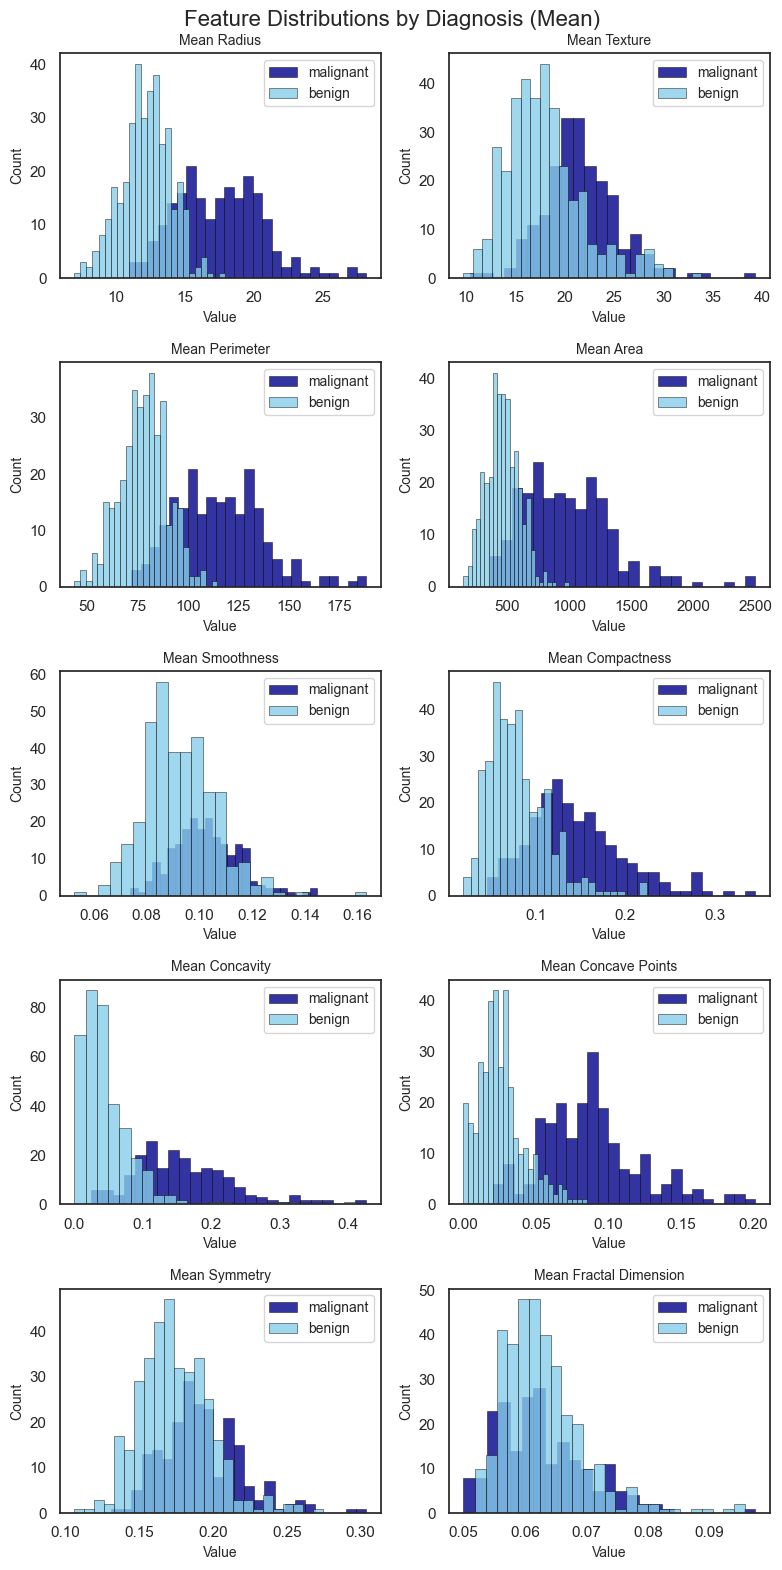

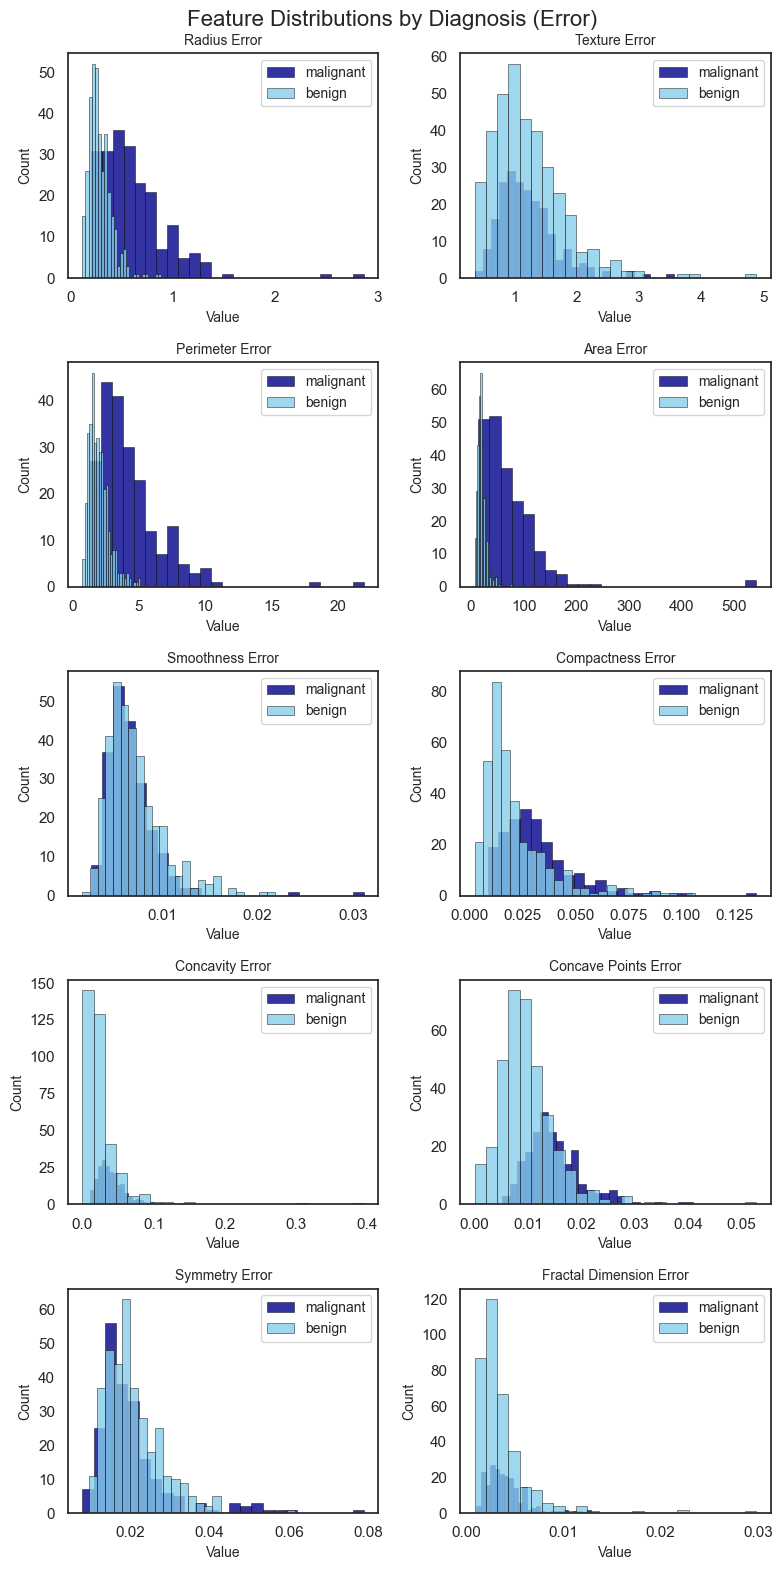

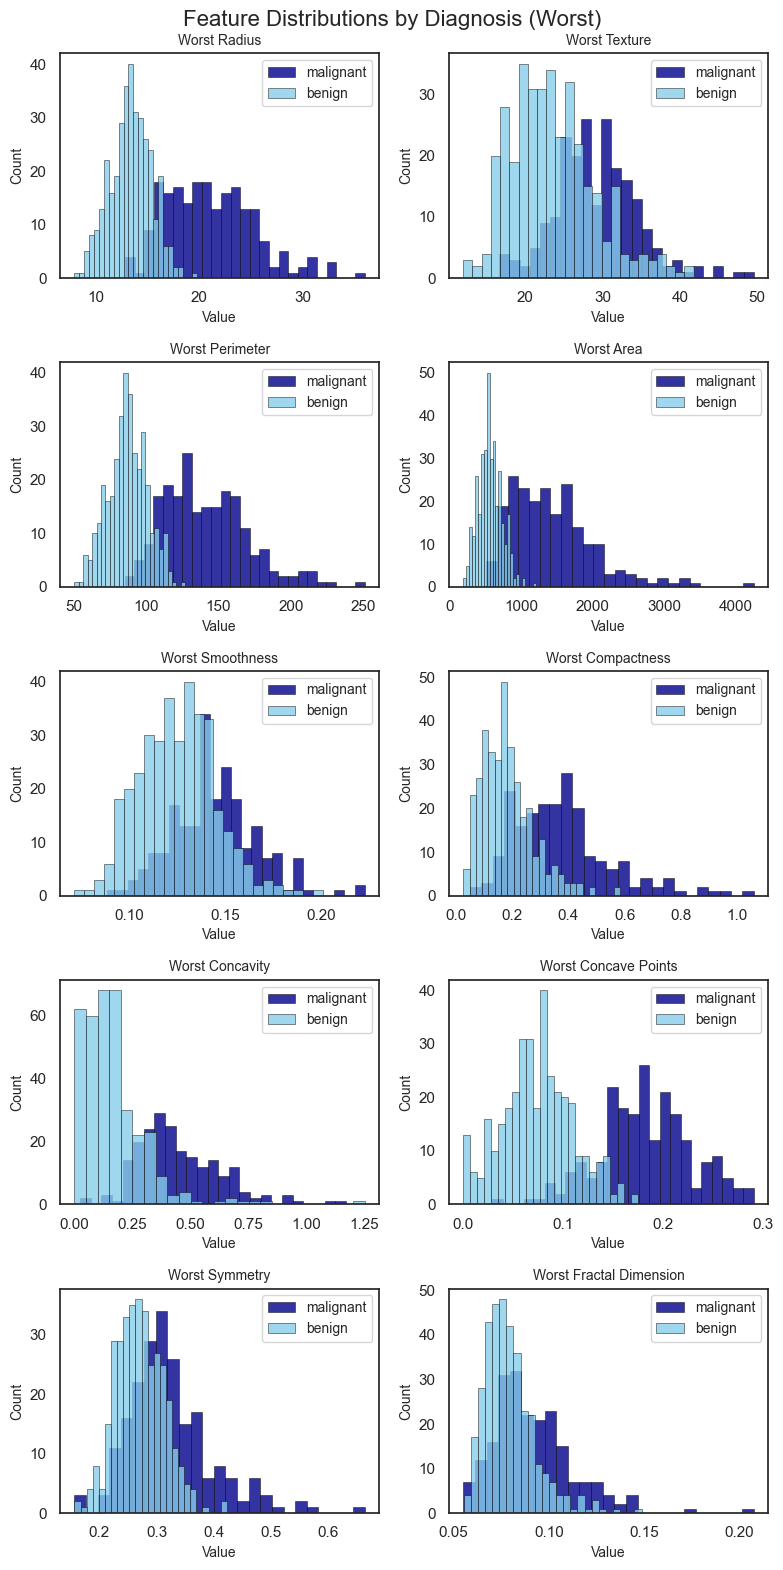

In [118]:
## Feature Distributions

# create one figure per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    fig, axes = plt.subplots(5, 2, figsize=(8, 16))
    axes = axes.flatten()

    # create one histogram per feature
    for i, ft in enumerate (feats):
        for dx, col in cols.items(): 
            
            # split features by class
            subset = df[df["diagnosis"] == dx][ft]

            axes[i].hist(
                subset,
                bins = 25,
                alpha = 0.8,
                color = col,
                label = dx,
                edgecolor = "black",
                linewidth = 0.4
            )
        
        # add sub-figure titles, axes, legend
        axes[i].set_title(ft.title(), fontsize=10)
        axes[i].set_xlabel('Value', fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].legend(fontsize=10)

    # add figure title
    plt.suptitle(f"Feature Distributions by Diagnosis ({m.title()})", fontsize=16)
    plt.tight_layout()
    plt.show()

### Observations:
**Mean**:
- discriminative: 

**Error**:
- discriminative: 

**Worst**:
- discriminative: radius, perimeter, area, concave points

## 3.2 Boxplots & Outlier Detection
Next, we will check for potential outliers in the dataset using boxplots, which highlight the median (red line), spread (IQR), and potential outliers (> IQR * 1.5) for each feature across classes. 
<!-- could potentially flag outliers as a column -->

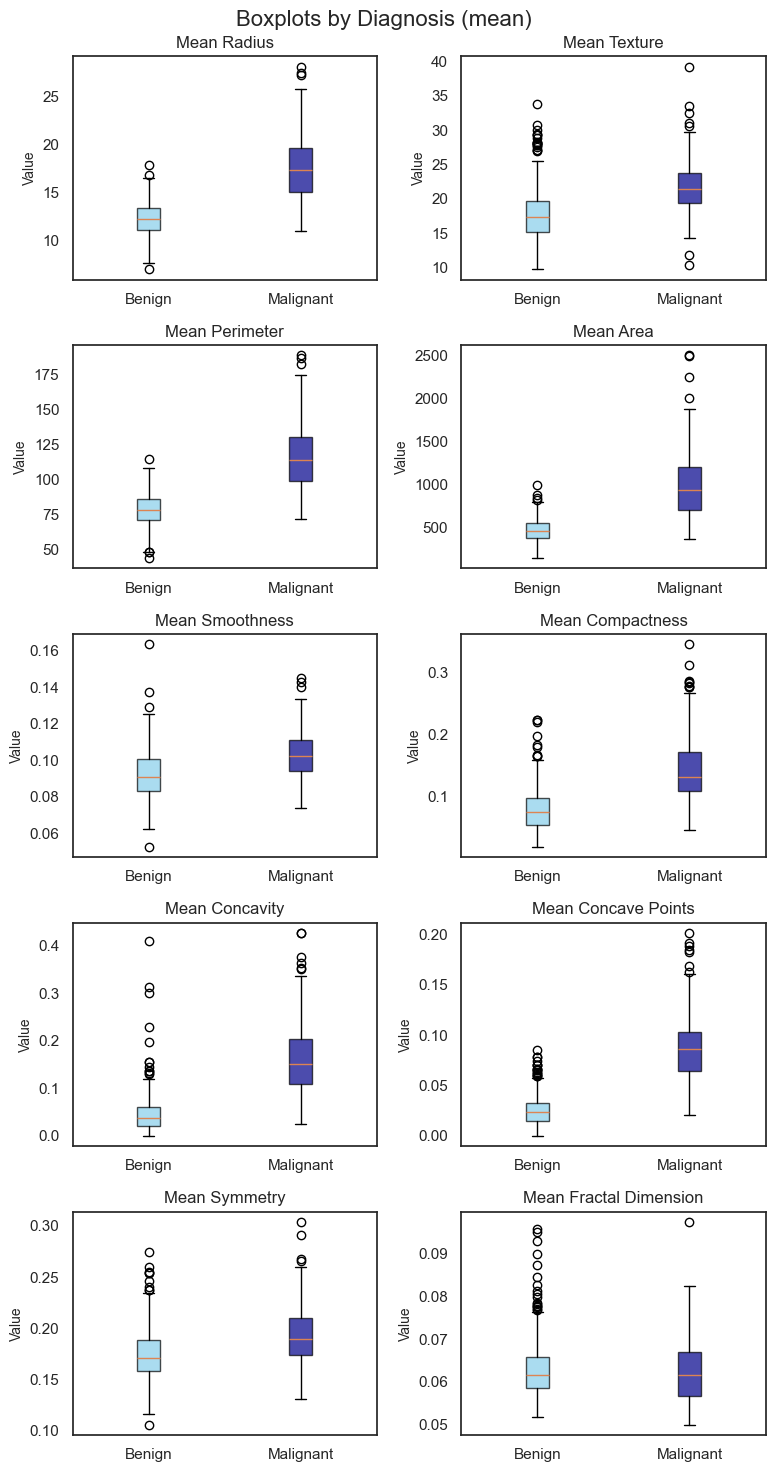

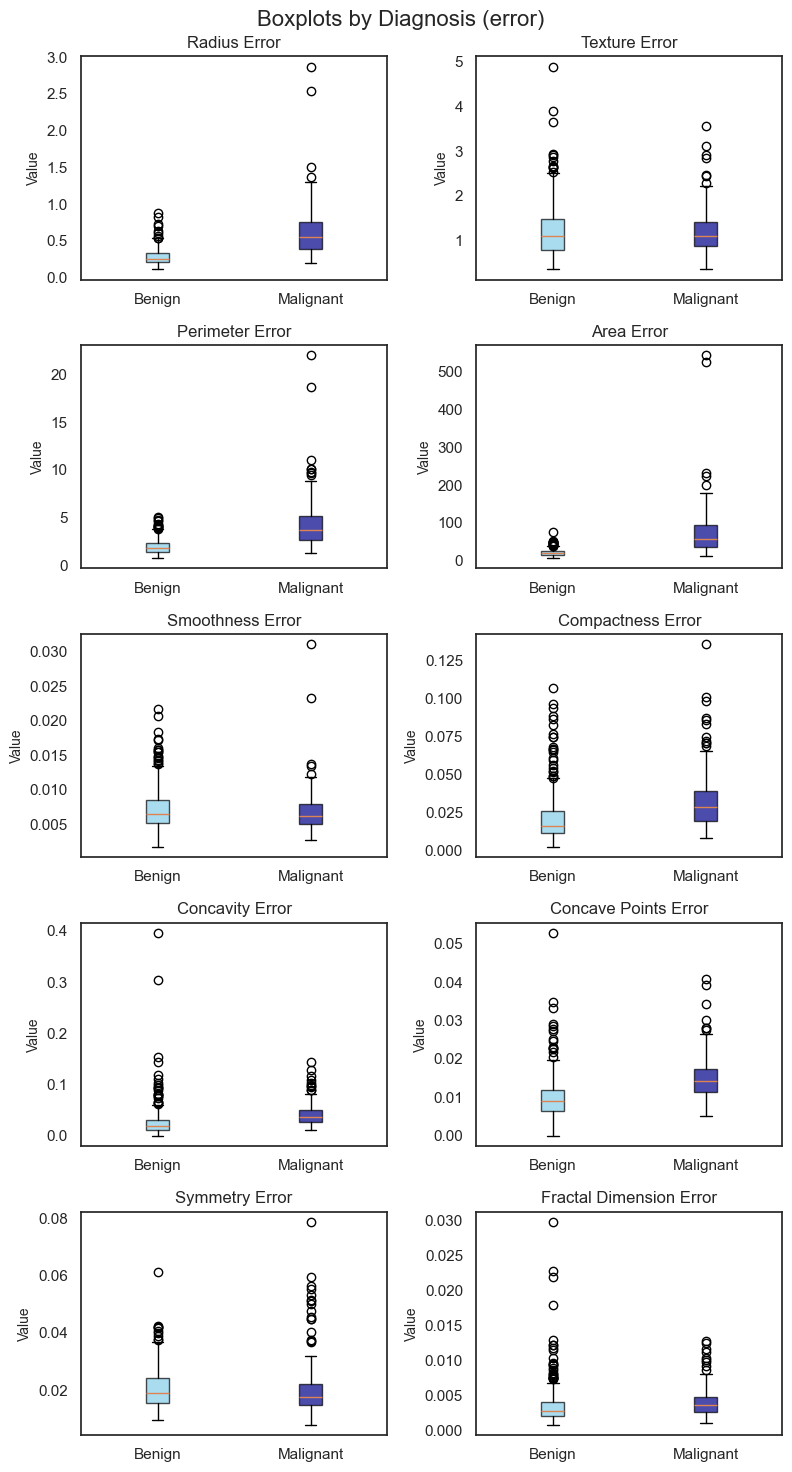

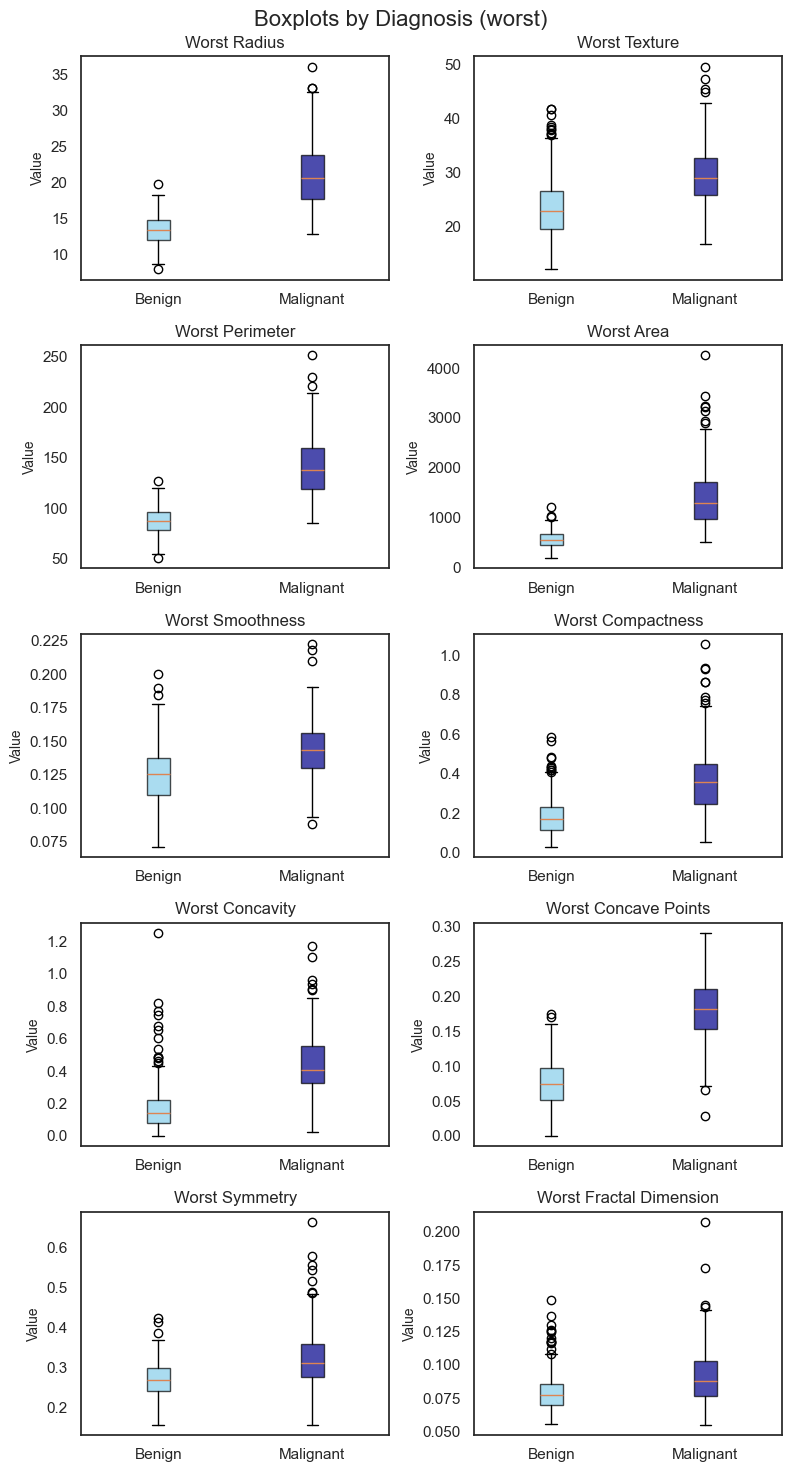

In [ ]:
## Boxplots & Outlier Detection

# create one figure per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    fig, axes = plt.subplots(5, 2, figsize = (8, 15))
    axes = axes.flatten()

    for i, ft in enumerate(feats):

        # split the data by diagnosis
        ben = df[df["diagnosis"] == "benign"][ft]
        mal = df[df["diagnosis"] == "malignant"][ft]

        # draw the boxplot
        bp = axes[i].boxplot(
            [ben, mal],
            tick_labels = ["Benign", "Malignant"],
            patch_artist = True,
            notch = False
        )
    
        # set boxes
        bp["boxes"][0].set_facecolor(cols["benign"])
        bp["boxes"][0].set_alpha(0.7)
        bp["boxes"][1].set_facecolor(cols["malignant"])
        bp["boxes"][1].set_alpha(0.7)

        # add title/label
        axes[i].set_title(ft.title(), fontsize=12)
        axes[i].set_ylabel("Value", fontsize=10)

        # turn off gridlines
        axes[i].set_axisbelow(False)
        axes[i].grid(False)

    plt.suptitle(f"Boxplots by Diagnosis ({m})", fontsize=16)
    plt.tight_layout()
    plt.show()


### Observations:


## X.X Distribution Scaling Considerations
### Raw (Unstandardized)

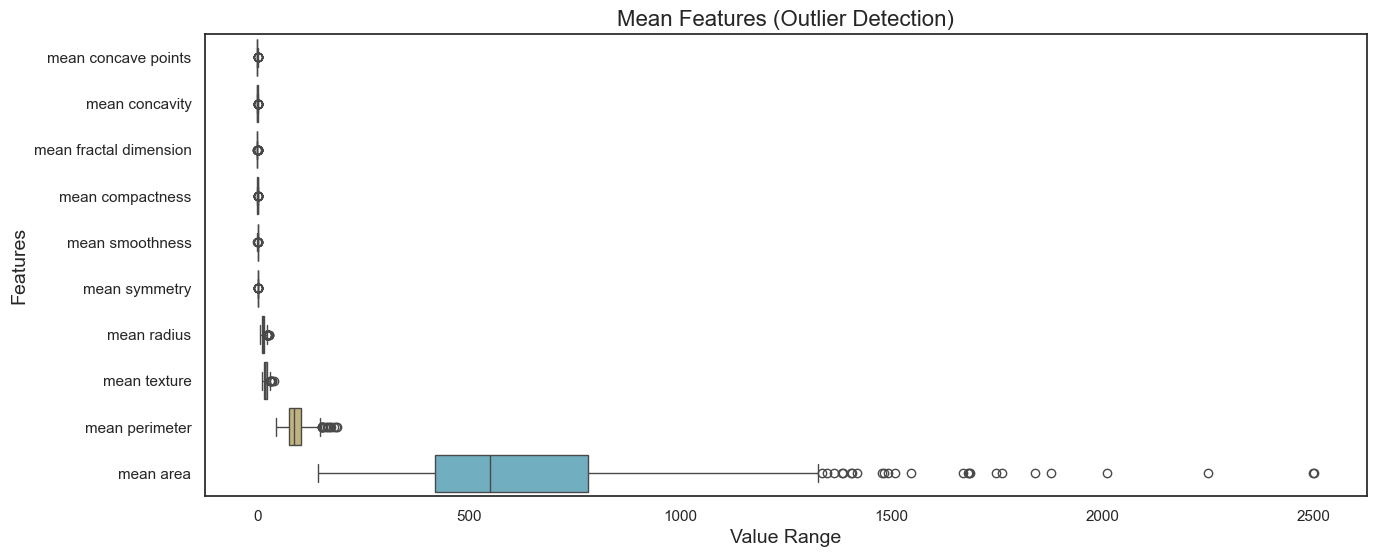

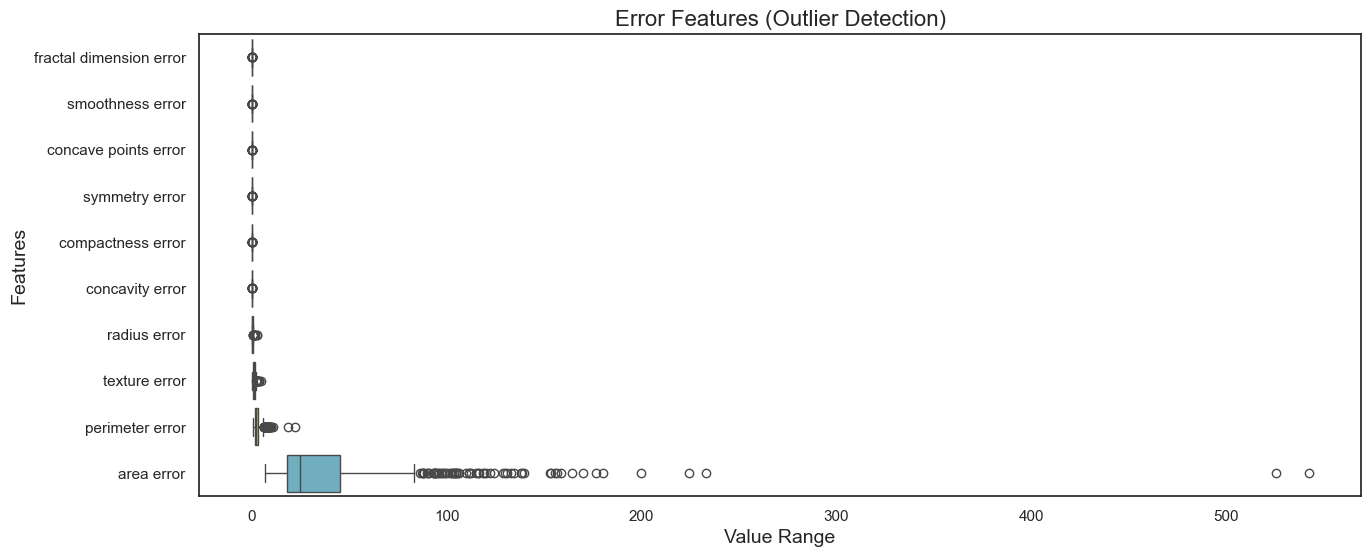

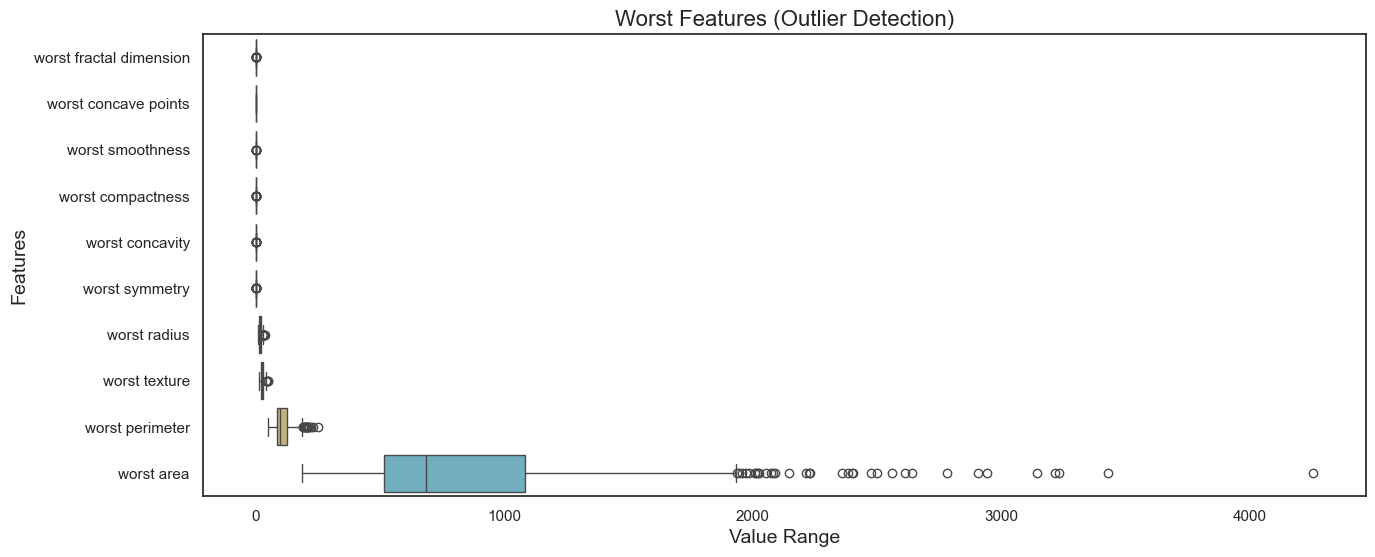

In [116]:
## Boxplot visualization of outliers

# create one boxplot per measure
for m in measures:
    feats = [col for col in df.columns if col.__contains__(m)]

    plt.figure(figsize=(15, 6))
    ordered_feats = df[feats].median().sort_values().index

    sns.boxplot(data=df[ordered_feats], orient="h")
    plt.title(f"{m.title()} Features (Outlier Detection)", fontsize=16)
    plt.xlabel("Value Range", fontsize=14)
    plt.ylabel("Features", fontsize=14)
    plt.show()

### Standardized 

# 4. Feature Correlation Analysis

## 4.1 Correlation Heatmap
High correlations between features can lead to multicollinearity, which will make certain models unstable and potentially misleading.

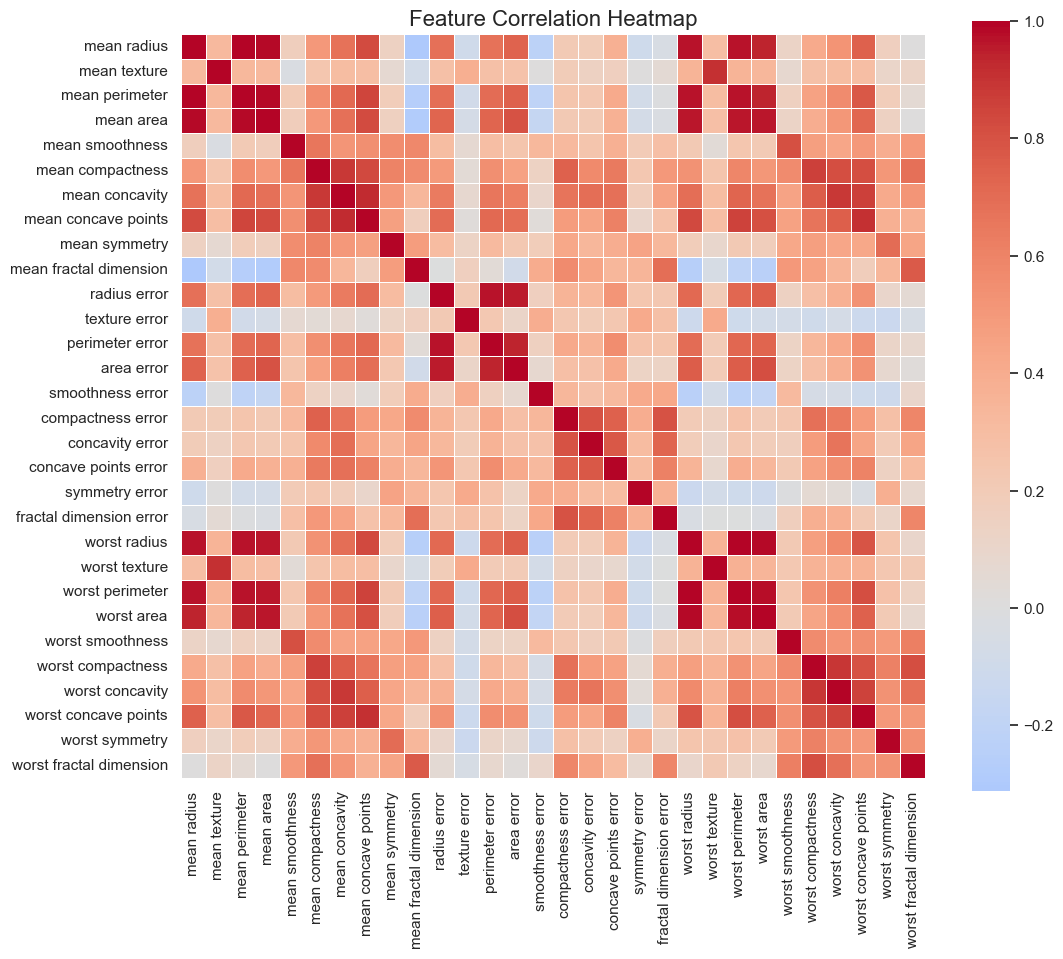

In [52]:
plt.figure(figsize=(12, 10))

corr = df.drop(columns = "diagnosis").corr()

sns.heatmap(
    corr,
    cmap = "coolwarm",
    center = 0,
    square = True,
    linewidths = 0.5
)

plt.title("Feature Correlation Heatmap", fontsize = 16)
plt.show()

### Observations:
- radius, perimeter, and area are highly correlated - expected since they measure the same physical property
- a tree-based model can handle multicollinearity, but will affect logistic regression - use StandardScaler to handle scale differences

# 5. Preliminary Feature Importance

## 5.1 Key Feature Relationships
Visualize how pairs of features separate the classes, along with a plot of the distributions.

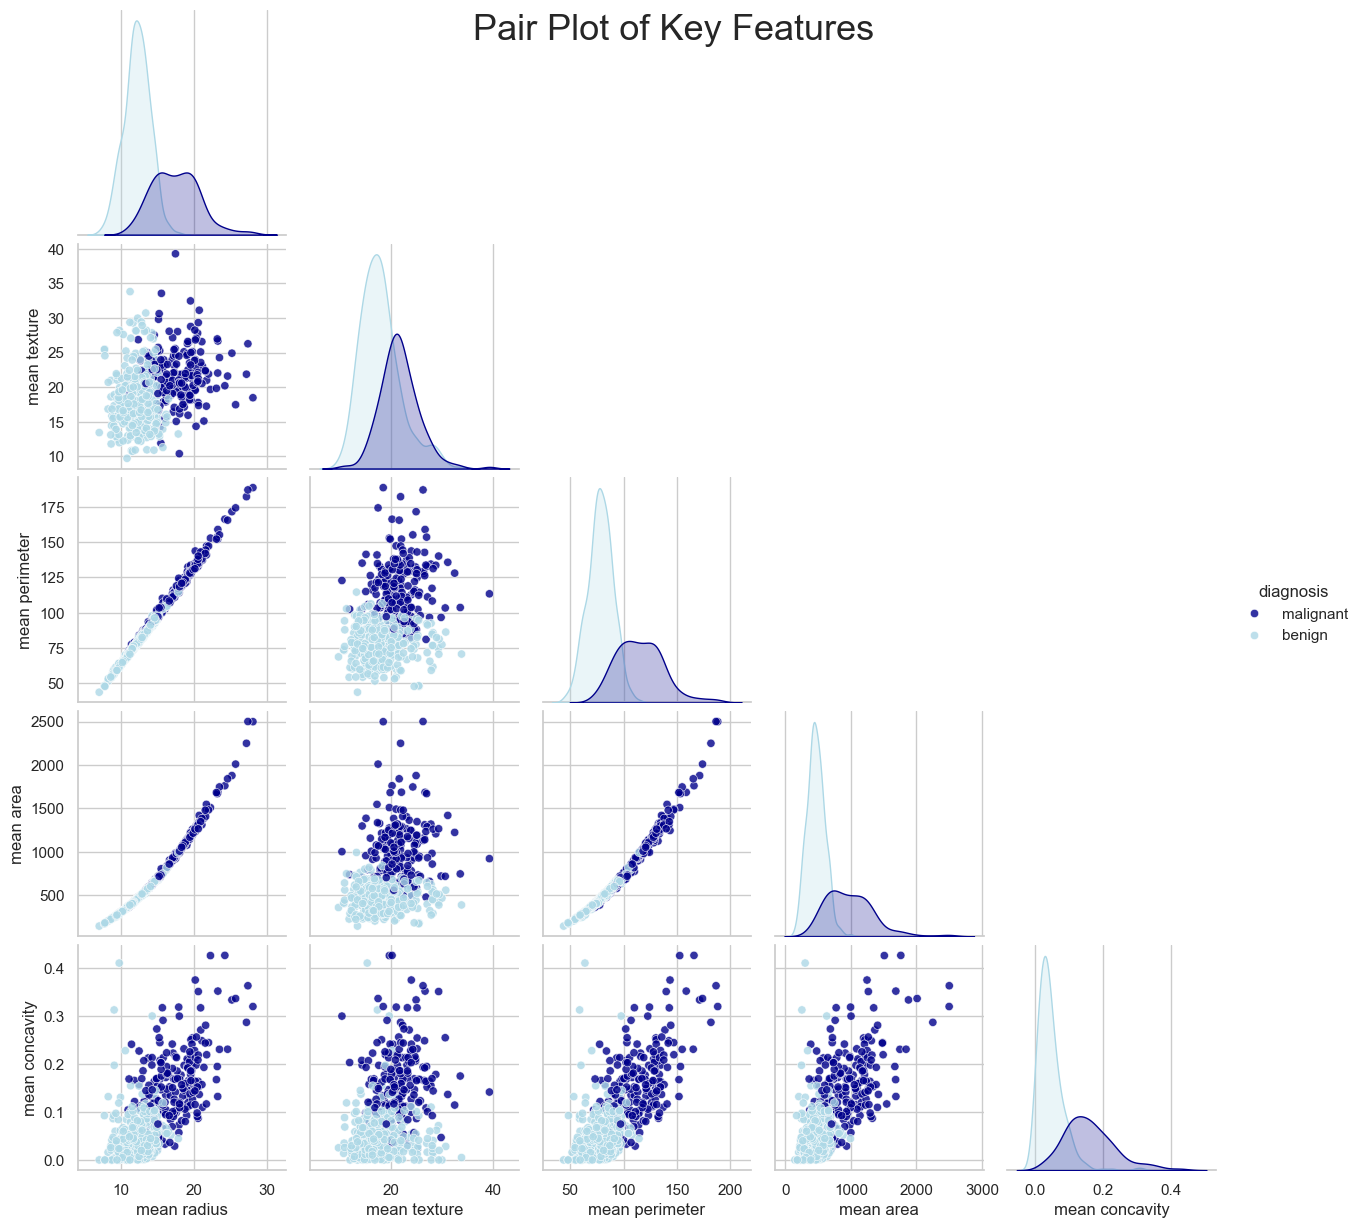

In [ ]:
# select some strongly discriminative features
key_ft = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity"]

sns.pairplot(
    df, 
    vars = key_ft,
    hue = "diagnosis",
    diag_kind = "kde",
    corner = True,
    plot_kws = {"alpha":0.8},
    palette = cols
)

plt.grid(None)
plt.suptitle("Pair Plot of Key Features", fontsize = 26)
plt.show()

### Observations:

# 6. Potential Risks & Unknowns

<!-- ## 6.1 Summary of Exploratory Data Analysis
## 6.2 Dataset-Level Risks
## 6.3 Modeling Risks
## 6.4 Ethical & Practical Risks -->

# 7. Proposed Modeling Plan

<!-- ## 7.1 Metrics
## 7.2 Models
## 7.3 Evaluation
## 7.4 Interpretability, Reliability, Robustness
## 7.5 Stretch Goals -->

--- 

Author: SE Creighton